# OpenMP Grid Search Analysis

This notebook loads the averaged results from `hashjoin_omp_loop.csv` and `hashjoin_omp_task.csv`. The plots are generated separately for each execution type so the goal stays parameter reduction inside each implementation, not a direct comparison between implementations.

In [7]:
from pathlib import Path
import re

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

CSV_FILES = [
    "hashjoin_omp_loop.csv",
    "hashjoin_omp_task.csv",
]
RESULTS_CANDIDATES = [
    Path("results"),
    Path("src/results"),
    Path("../results"),
]
IMG_CANDIDATES = [
    Path("img/omp_statistics"),
    Path("src/img/omp_statistics"),
    Path("../img/omp_statistics"),
]

RESULTS_DIR = None
csv_paths = []
for candidate_dir in RESULTS_CANDIDATES:
    paths = [candidate_dir / name for name in CSV_FILES]
    if all(path.exists() for path in paths):
        RESULTS_DIR = candidate_dir
        csv_paths = paths
        break

if RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"Could not find all OpenMP CSV files in: {searched}")

frames = []
for csv_path in csv_paths:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    frames.append(current_df)

raw_df = pd.concat(frames, ignore_index=True, sort=False)

# Keep schedule columns as strings; converting them to numeric would turn "static"/"dynamic" into NaN.
numeric_columns = [
    "checksum1",
    "checksum2",
    "join_count",
    "join_threads",
    "join_throughput",
    "join_time",
    "join_task_grain",
    "max_key",
    "nr",
    "ns",
    "offset_task_grain",
    "partition_block_size",
    "partition_chunk",
    "partition_task_grain",
    "partition_threads",
    "partition_throughput",
    "time_sec",
    "total_throughput",
    "join_chunk",
    "partition_time",
]
for col in numeric_columns:
    if col in raw_df.columns:
        raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

fallback_total_throughput = (raw_df["nr"] + raw_df["ns"]) / raw_df["time_sec"].where(raw_df["time_sec"] > 0)
if "total_throughput" not in raw_df.columns:
    raw_df["total_throughput"] = fallback_total_throughput
else:
    raw_df["total_throughput"] = raw_df["total_throughput"].fillna(fallback_total_throughput)

parameter_columns = [
    "exec_type",
    "nr",
    "ns",
    "max_key",
    "partition_threads",
    "join_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
    "partition_task_grain",
    "join_task_grain",
    "offset_task_grain",
]
parameter_columns = [col for col in parameter_columns if col in raw_df.columns]

validation_columns = [col for col in ["checksum1", "checksum2", "join_count"] if col in raw_df.columns]
group_columns = validation_columns + parameter_columns
metric_columns = [
    col for col in raw_df.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(raw_df[col])
]

avg_df = (
    raw_df.groupby(group_columns, as_index=False, dropna=False)
    .agg({col: "mean" for col in metric_columns})
    .sort_values(["exec_type", "time_sec"])
    .reset_index(drop=True)
)

exec_types = sorted(avg_df["exec_type"].dropna().unique())
metric = "time_sec"

for candidate in IMG_CANDIDATES:
    if candidate.parent.exists() or candidate.exists():
        IMG_DIR = candidate
        break
else:
    IMG_DIR = Path("img/omp_statistics")
IMG_DIR.mkdir(parents=True, exist_ok=True)

plot_counter = 0

def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return cleaned[:180] if cleaned else "plot"


def save_figure(fig, name):
    global plot_counter
    plot_counter += 1
    output_path = IMG_DIR / f"{plot_counter:02d}_{slugify(name)}.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")
    return output_path


def finish_plot(fig, name):
    output_path = save_figure(fig, name)
    display(Image(filename=str(output_path)))
    plt.close(fig)

print(f"[Loaded {raw_df.shape[0]} raw rows from {RESULTS_DIR}]")
print(f"[Averaged to {avg_df.shape[0]} parameter combinations]")
print(f"exec_type: {exec_types}")
print(f"image_output_dir: {IMG_DIR}")

summary_df = (
    avg_df.groupby("exec_type", as_index=False)
    .agg(
        combinations=("time_sec", "size"),
        best_time_sec=("time_sec", "min"),
        median_time_sec=("time_sec", "median"),
        best_total_throughput=("total_throughput", "max"),
    )
)
display(summary_df)


[Loaded 432 raw rows from results]
[Averaged to 432 parameter combinations]
exec_type: ['omp_loop', 'omp_task']
image_output_dir: img/omp_statistics


,exec_type,combinations,best_time_sec,median_time_sec,best_total_throughput
0,omp_loop,144,0.114287,0.122775,1.749980e+08
1,omp_task,288,0.118965,0.125395,1.681169e+08


## Best Configurations

These tables show the best averaged configurations inside each OpenMP implementation. They are useful for choosing a smaller follow-up grid.

In [8]:
top_n = 20
config_columns = [
    "exec_type",
    "time_sec",
    "partition_time",
    "join_time",
    "total_throughput",
    "partition_threads",
    "join_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
    "partition_task_grain",
    "join_task_grain",
]
config_columns = [col for col in config_columns if col in avg_df.columns]

for exec_type in exec_types:
    subdf = avg_df[avg_df["exec_type"] == exec_type].copy()
    relevant_columns = [
        col for col in config_columns
        if col == "exec_type" or subdf[col].notna().any()
    ]
    print(f"\nBest {top_n} configurations for {exec_type}")
    display(
        subdf
        .sort_values("time_sec")
        [relevant_columns]
        .head(top_n)
        .reset_index(drop=True)
    )



Best 20 configurations for omp_loop


,exec_type,time_sec,partition_time,join_time,total_throughput,partition_threads,join_threads,partition_schedule,join_schedule,partition_chunk,join_chunk,partition_block_size
0,omp_loop,0.114287,0.076931,0.036322,1.749980e+08,32,32,guided,static,0,0,32768
1,omp_loop,0.114974,0.076630,0.037607,1.739516e+08,32,32,guided,auto,0,0,32768
2,omp_loop,0.115153,0.077705,0.036739,1.736816e+08,32,32,auto,guided,0,0,32768
3,omp_loop,0.115165,0.078160,0.036038,1.736637e+08,32,32,static,auto,0,0,32768
4,omp_loop,0.115274,0.077889,0.036399,1.735002e+08,32,32,static,auto,0,8,32768
5,omp_loop,0.115911,0.078215,0.036693,1.725456e+08,32,32,auto,static,8,0,32768
6,omp_loop,0.115934,0.078437,0.036529,1.725124e+08,32,32,auto,guided,8,0,32768
7,omp_loop,0.116081,0.078621,0.036409,1.722929e+08,32,32,static,guided,0,0,32768
8,omp_loop,0.116183,0.078314,0.036902,1.721427e+08,32,32,auto,auto,8,8,32768
9,omp_loop,0.116229,0.077899,0.037317,1.720739e+08,32,32,guided,auto,0,8,32768



Best 20 configurations for omp_task


,exec_type,time_sec,partition_time,join_time,total_throughput,partition_threads,join_threads,partition_schedule,join_schedule,partition_chunk,join_chunk,partition_block_size,partition_task_grain,join_task_grain
0,omp_task,0.118965,0.078517,0.039450,1.681169e+08,64,32,auto,auto,0,0,32768,1.0,1.0
1,omp_task,0.118987,0.078560,0.039469,1.680853e+08,64,32,guided,guided,0,8,32768,1.0,8.0
2,omp_task,0.119125,0.078277,0.039579,1.678902e+08,64,32,static,static,0,0,32768,1.0,1.0
3,omp_task,0.119183,0.079736,0.038677,1.678093e+08,64,64,auto,auto,8,8,16384,8.0,8.0
4,omp_task,0.119276,0.078304,0.039827,1.676787e+08,64,64,static,auto,0,8,32768,1.0,8.0
5,omp_task,0.119530,0.079637,0.038879,1.673221e+08,32,32,static,guided,0,0,32768,1.0,1.0
6,omp_task,0.119901,0.080571,0.038247,1.668045e+08,64,64,auto,guided,0,8,16384,1.0,8.0
7,omp_task,0.119902,0.079794,0.039065,1.668028e+08,32,32,guided,auto,0,8,32768,1.0,8.0
8,omp_task,0.119954,0.079986,0.039111,1.667311e+08,64,64,guided,auto,0,8,32768,1.0,8.0
9,omp_task,0.120016,0.080523,0.038465,1.666448e+08,64,64,static,guided,0,8,32768,1.0,8.0


## Thread Grid

Each heatmap shows the best averaged time achievable for a `(partition_threads, join_threads)` pair after minimizing over the remaining parameters for that same execution type.

[saved] img/omp_statistics/01_omp_loop_best_time_thread_heatmap.png


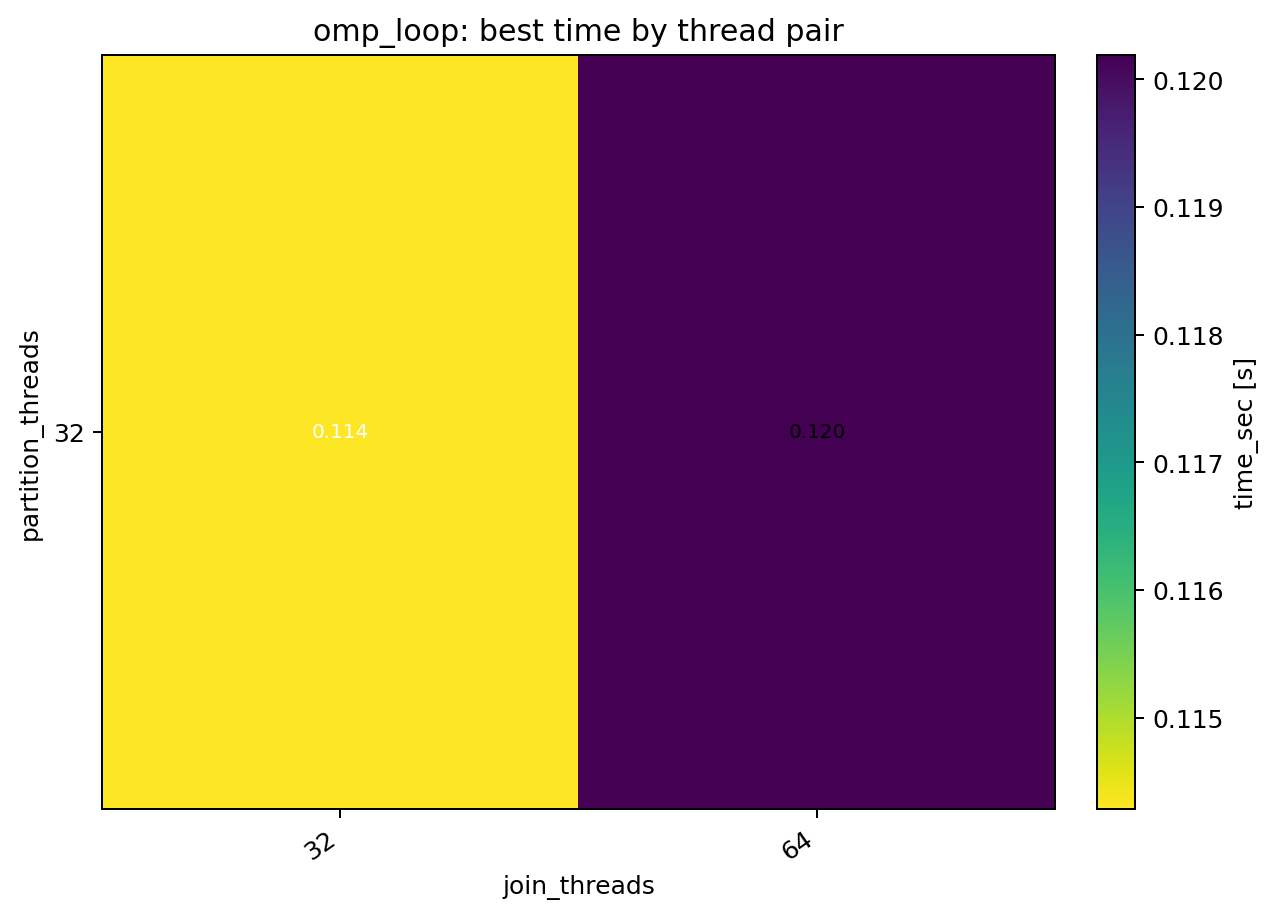

[saved] img/omp_statistics/02_omp_task_best_time_thread_heatmap.png


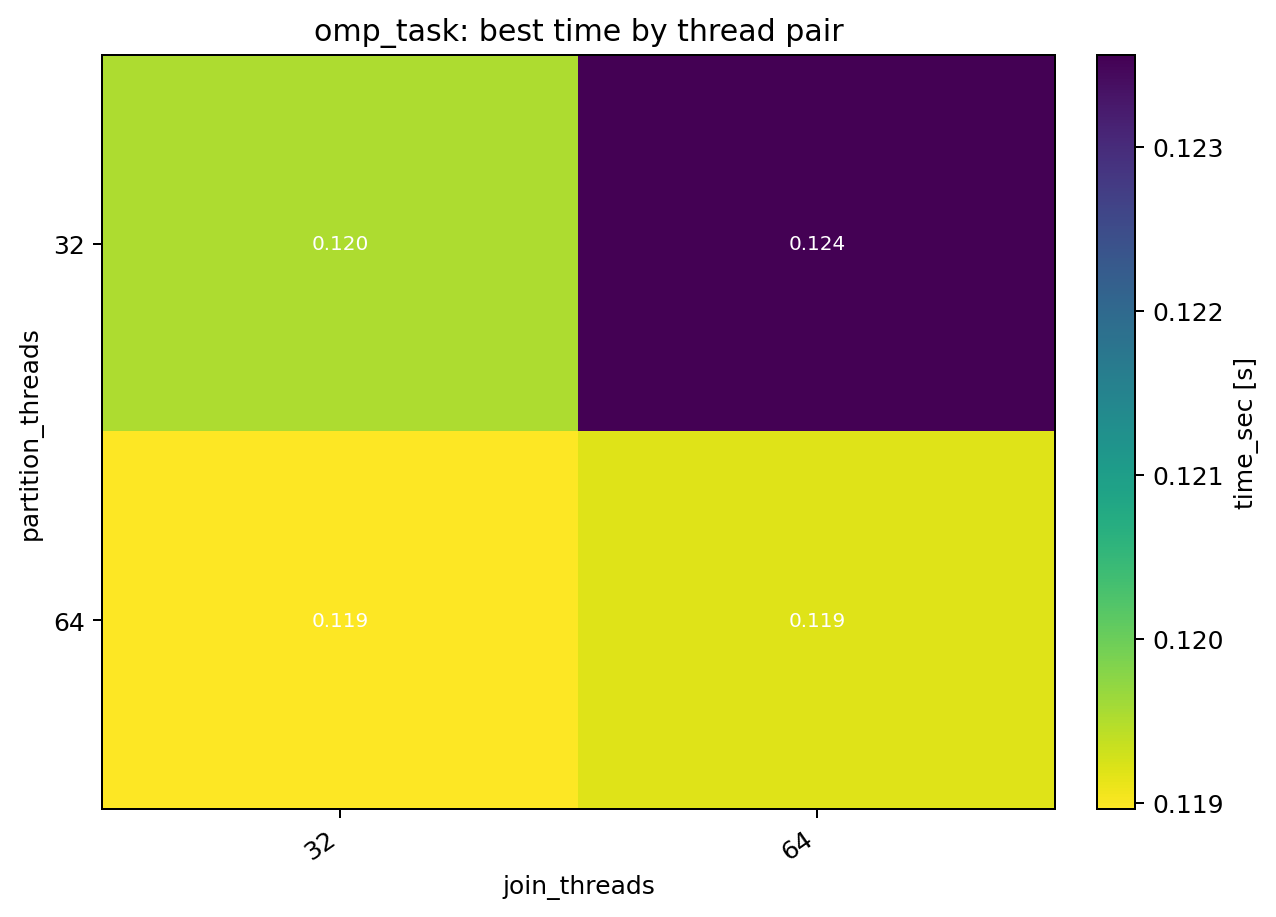

In [9]:
def format_axis_value(value):
    if pd.isna(value):
        return "NA"
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value)


def heatmap_from_table(ax, table, title, cbar_label="time_sec [s]", cmap="viridis_r"):
    image = ax.imshow(table.values, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels([format_axis_value(v) for v in table.columns], rotation=35, ha="right")
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels([format_axis_value(v) for v in table.index])

    finite_values = pd.Series(table.to_numpy().ravel()).dropna()
    threshold = finite_values.min() * 1.05 if not finite_values.empty else None
    for row_idx, row_value in enumerate(table.index):
        for col_idx, col_value in enumerate(table.columns):
            value = table.loc[row_value, col_value]
            if pd.notna(value):
                text_color = "white" if threshold is not None and value <= threshold else "black"
                ax.text(col_idx, row_idx, f"{value:.3f}", ha="center", va="center", fontsize=8, color=text_color)

    cbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)


for exec_type in exec_types:
    subdf = avg_df[avg_df["exec_type"] == exec_type].copy()
    table = subdf.pivot_table(
        index="partition_threads",
        columns="join_threads",
        values="time_sec",
        aggfunc="min",
    ).sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    heatmap_from_table(ax, table, f"{exec_type}: best time by thread pair")
    ax.set_xlabel("join_threads")
    ax.set_ylabel("partition_threads")
    fig.tight_layout()
    finish_plot(fig, f"{exec_type}_best_time_thread_heatmap")


## Parameter Sensitivity

For each parameter value, bars show the median averaged runtime across the rest of the grid and dots show the best runtime found with that value. Lower and flatter values are safer candidates for a reduced grid.

[saved] img/omp_statistics/03_omp_loop_parameter_sensitivity.png


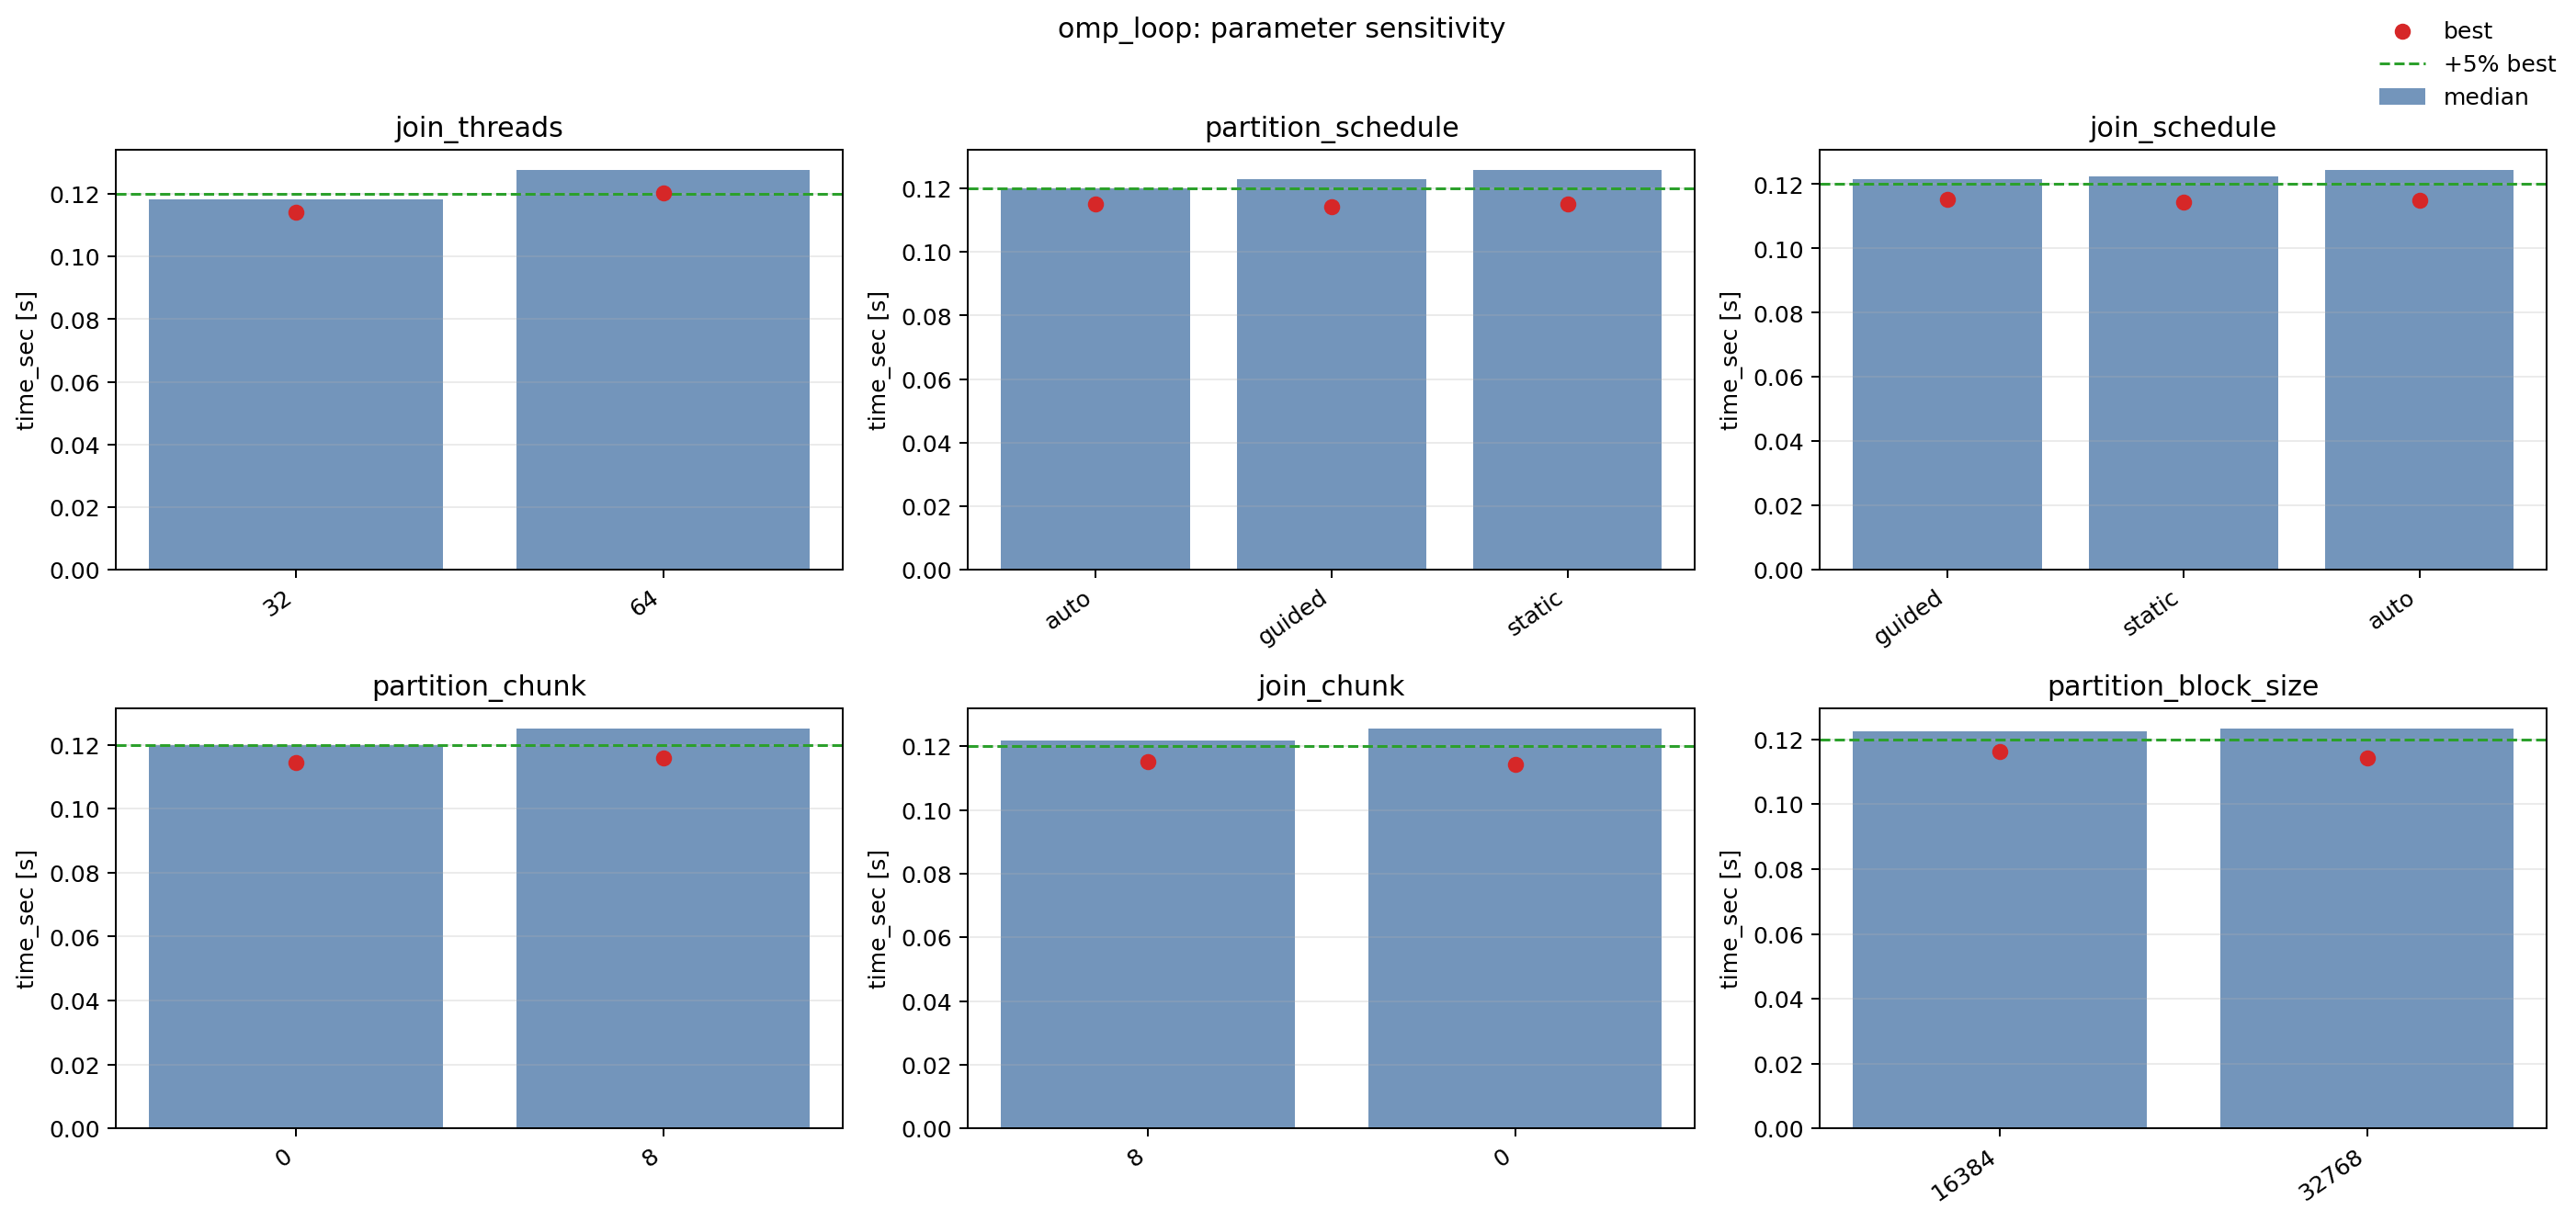

[saved] img/omp_statistics/04_omp_task_parameter_sensitivity.png


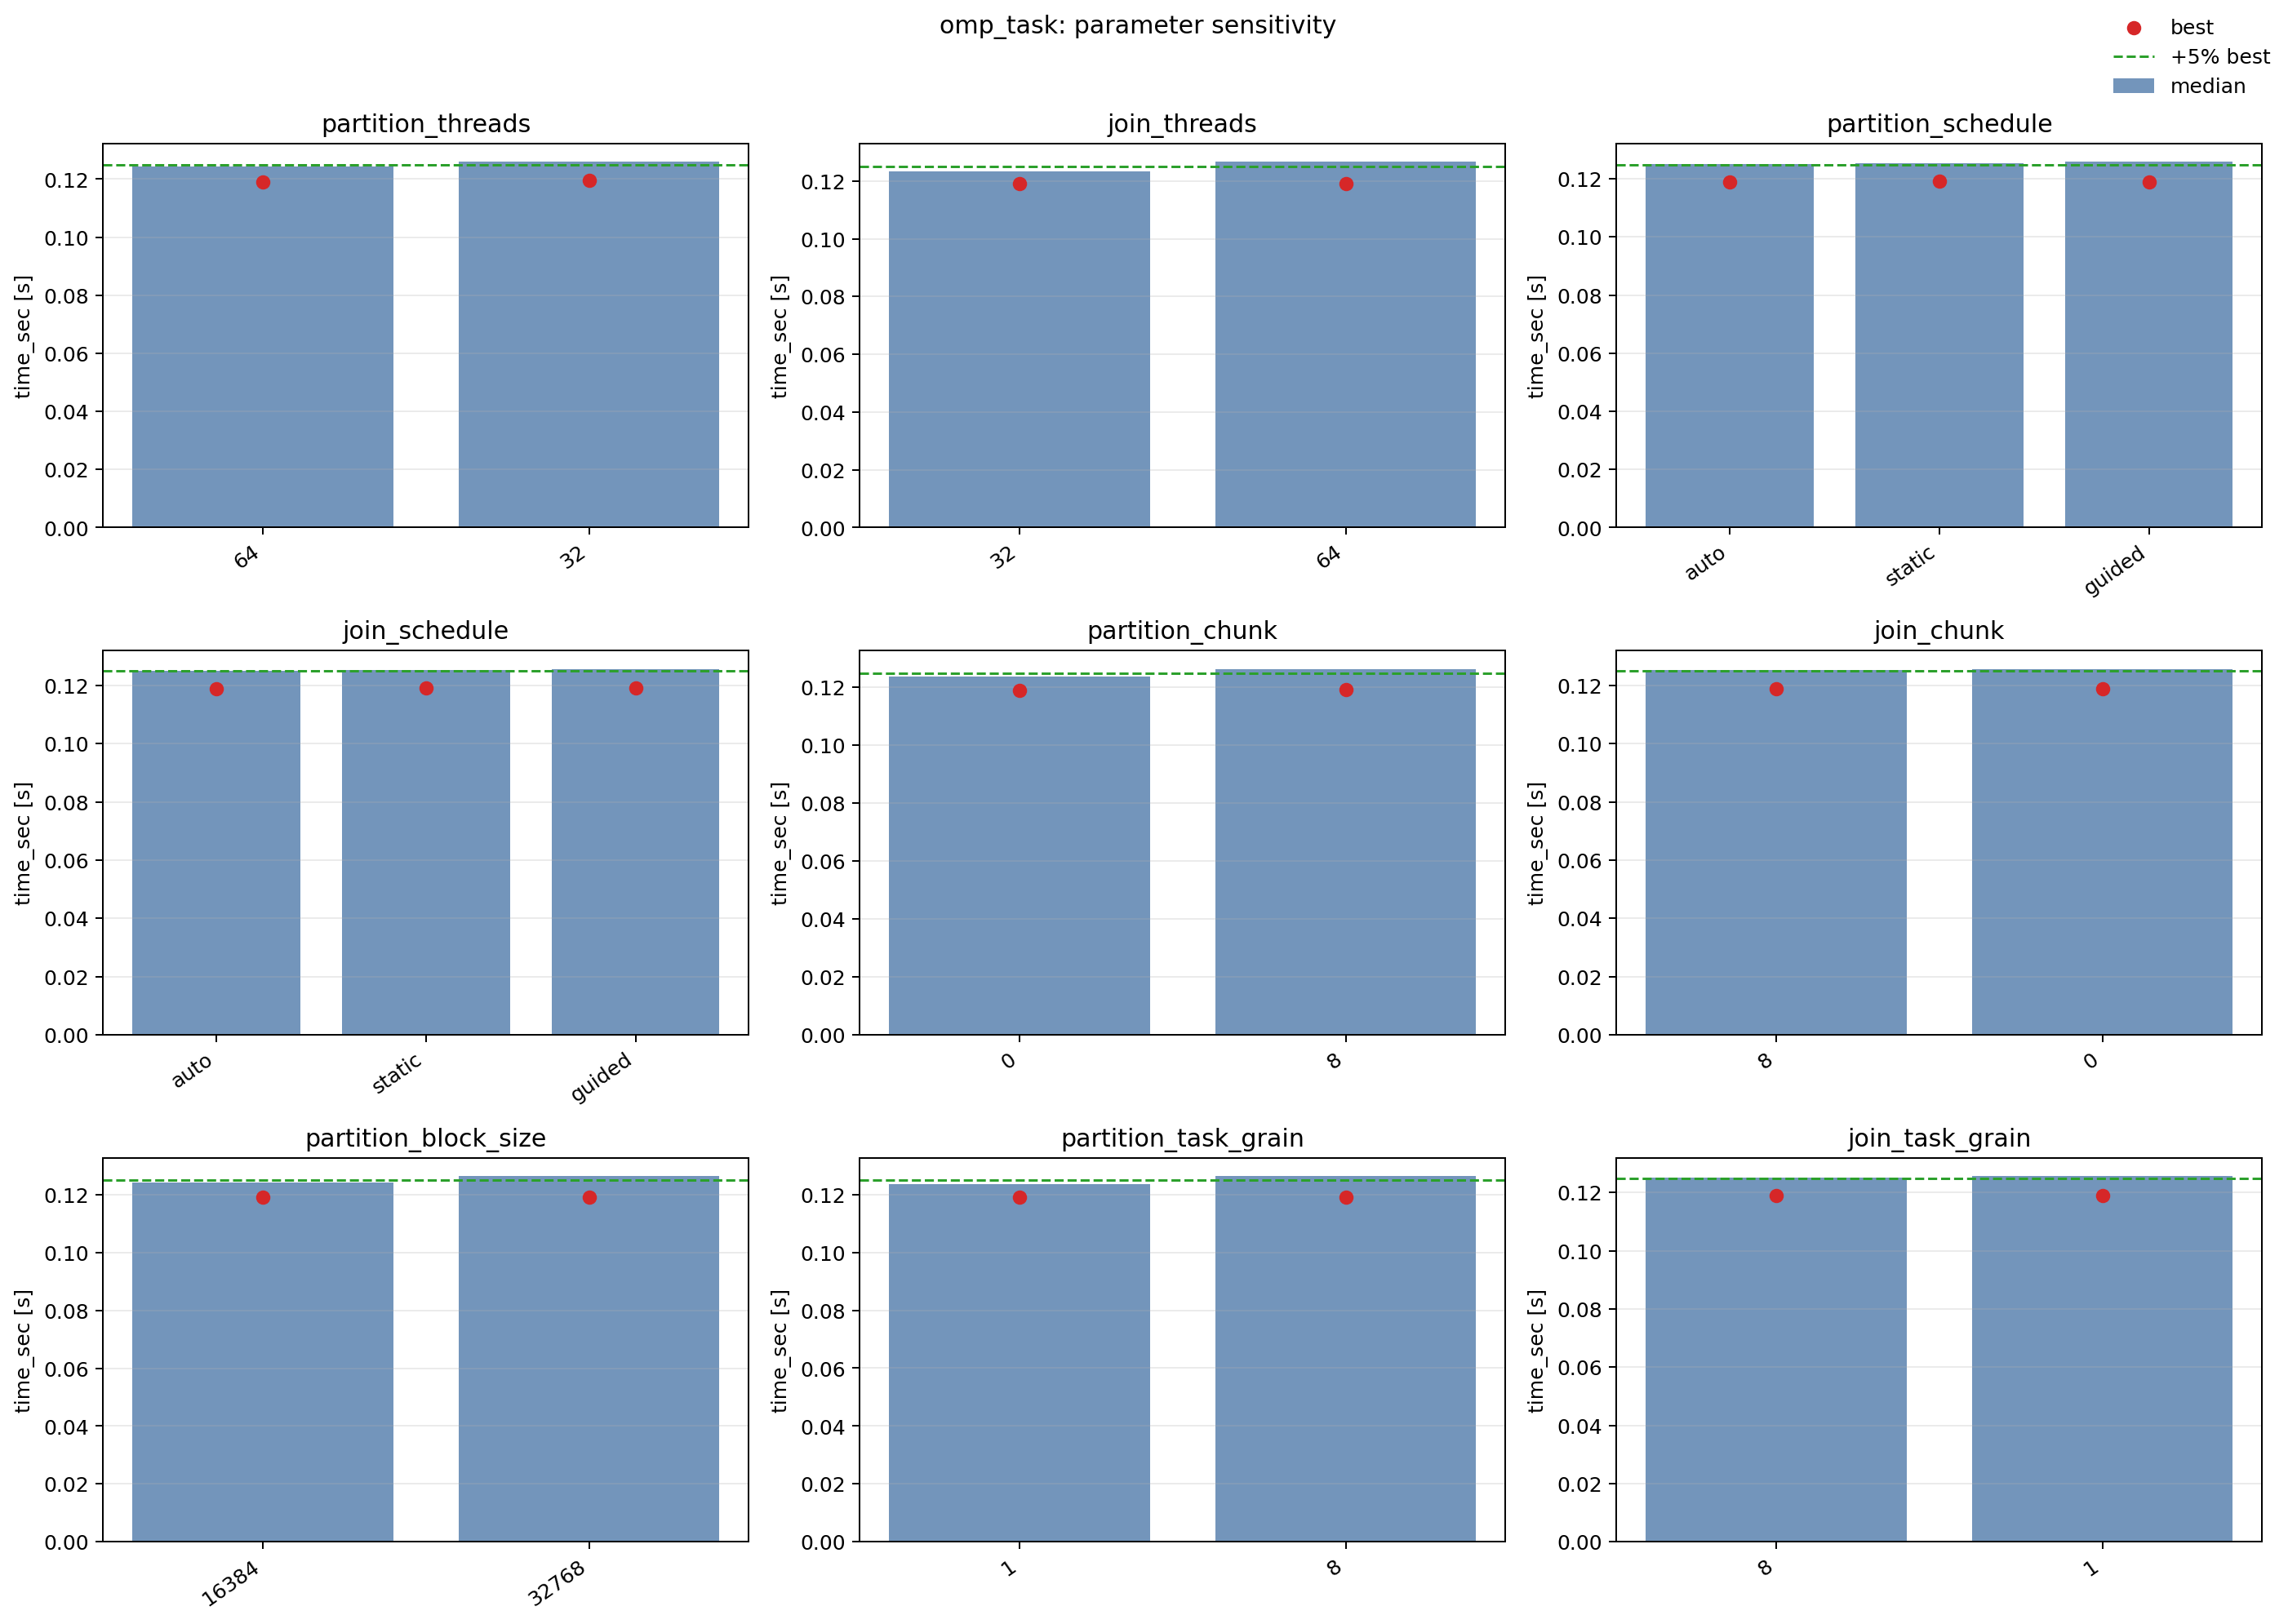

In [10]:
base_parameters = [
    "partition_threads",
    "join_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
    "partition_task_grain",
    "join_task_grain",
]

for exec_type in exec_types:
    subdf = avg_df[avg_df["exec_type"] == exec_type].copy()
    params = [col for col in base_parameters if col in subdf.columns and subdf[col].nunique(dropna=True) > 1]
    if not params:
        continue

    ncols = 3
    nrows = (len(params) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), squeeze=False)
    best_time = subdf["time_sec"].min()

    for ax, param in zip(axes.ravel(), params):
        param_df = (
            subdf.groupby(param, dropna=False)
            .agg(median_time=("time_sec", "median"), best_time=("time_sec", "min"), count=("time_sec", "size"))
            .reset_index()
            .sort_values("median_time")
        )
        x_positions = range(len(param_df))
        labels = [format_axis_value(v) for v in param_df[param]]
        ax.bar(x_positions, param_df["median_time"], color="#4C78A8", alpha=0.78, label="median")
        ax.scatter(x_positions, param_df["best_time"], color="#D62728", zorder=3, label="best")
        ax.axhline(best_time * 1.05, color="#2CA02C", linestyle="--", linewidth=1.2, label="+5% best")
        ax.set_title(param)
        ax.set_xticks(list(x_positions))
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.set_ylabel("time_sec [s]")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes.ravel()[len(params):]:
        ax.axis("off")

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)
    fig.suptitle(f"{exec_type}: parameter sensitivity", y=1.02)
    fig.tight_layout()
    finish_plot(fig, f"{exec_type}_parameter_sensitivity")


## Parameter Pair Heatmaps

These plots expose interactions that matter for reducing the grid: schedule pair, chunk pair, block size vs partition threads, and task grain pair where available.

[saved] img/omp_statistics/05_omp_loop_parameter_pair_heatmaps.png


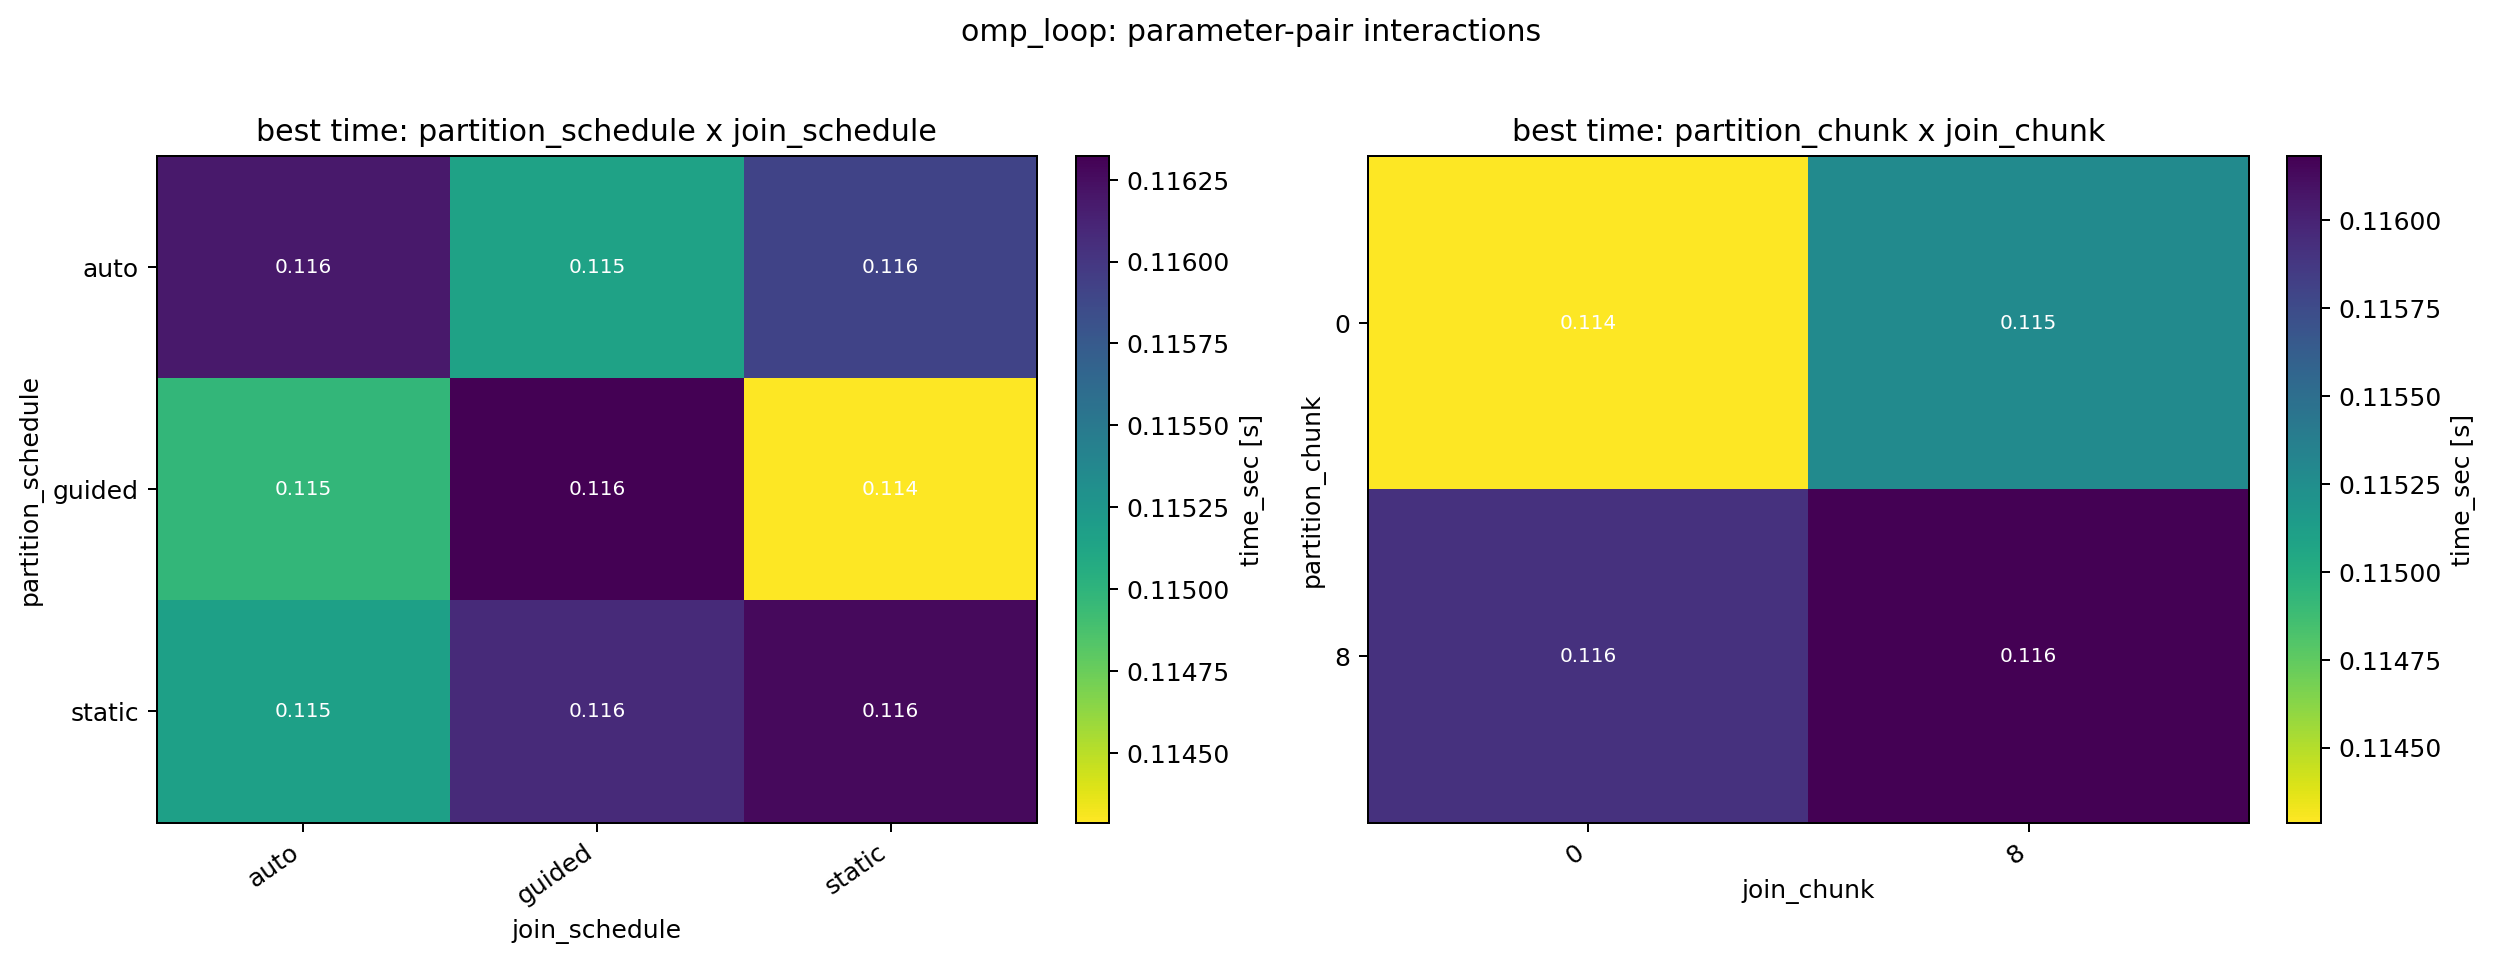

[saved] img/omp_statistics/06_omp_task_parameter_pair_heatmaps.png


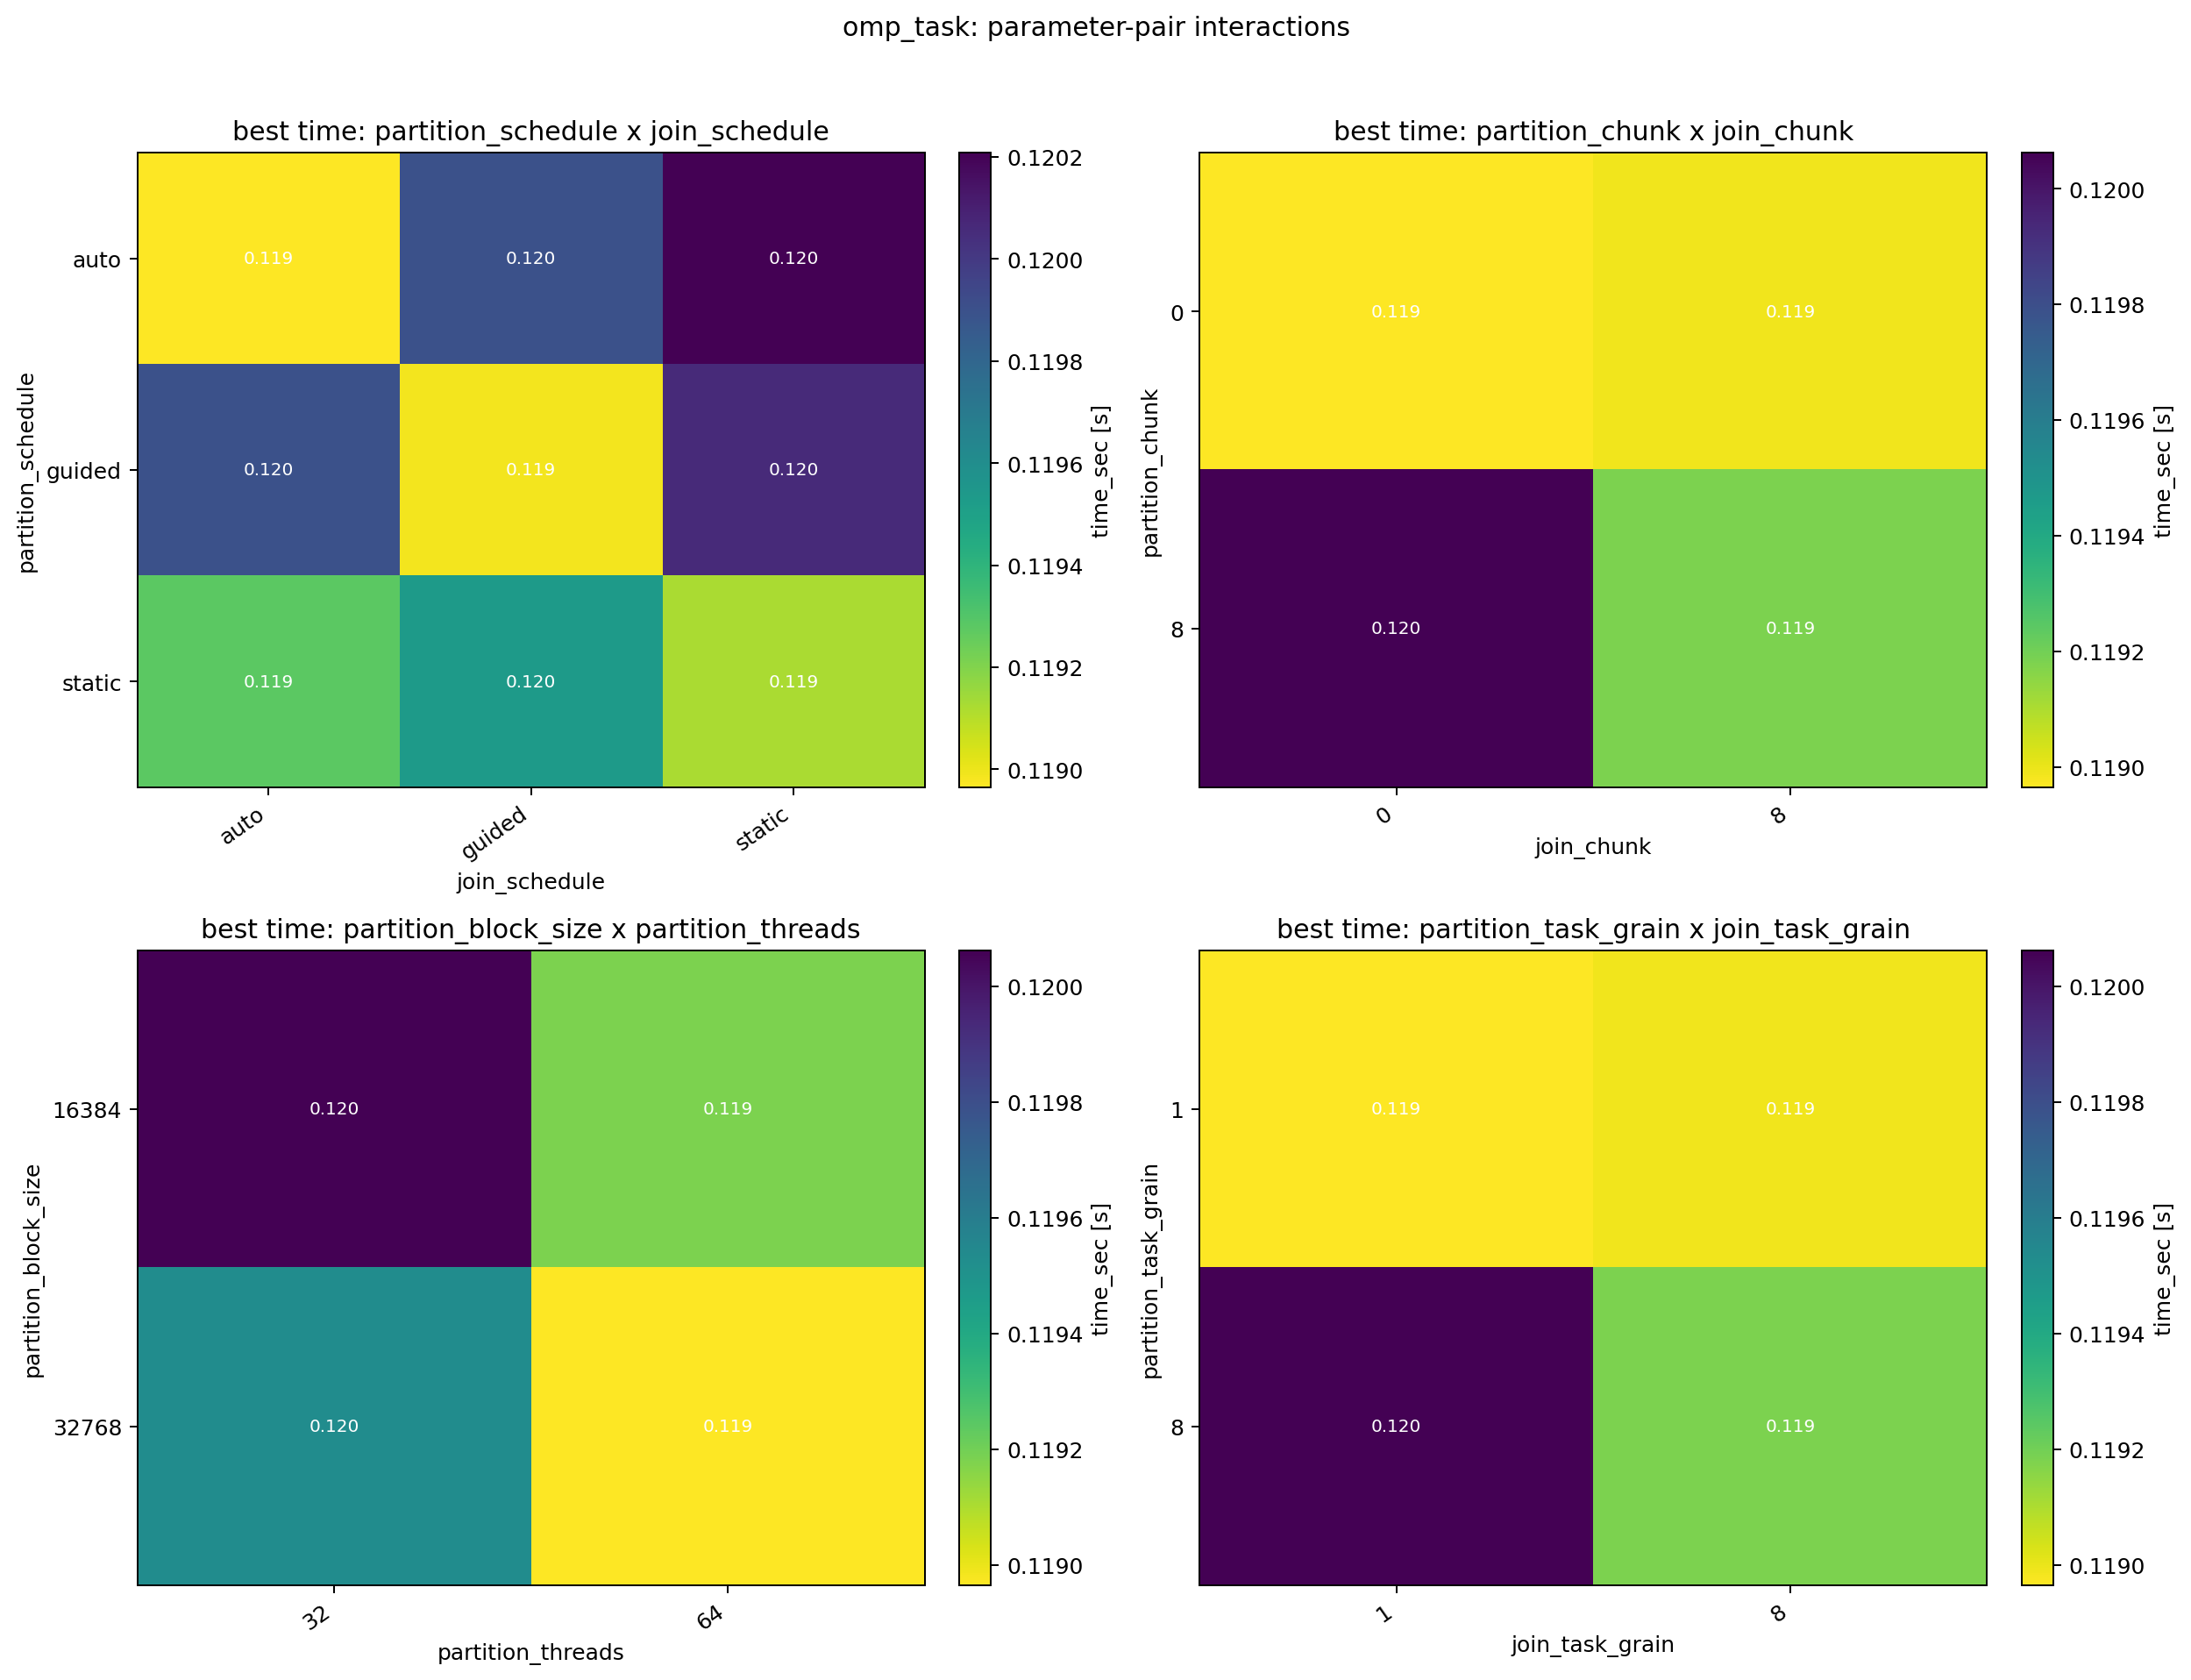

In [11]:
pair_candidates = [
    ("partition_schedule", "join_schedule"),
    ("partition_chunk", "join_chunk"),
    ("partition_block_size", "partition_threads"),
    ("partition_task_grain", "join_task_grain"),
]

for exec_type in exec_types:
    subdf = avg_df[avg_df["exec_type"] == exec_type].copy()
    pairs = [
        (row_col, col_col)
        for row_col, col_col in pair_candidates
        if row_col in subdf.columns
        and col_col in subdf.columns
        and subdf[row_col].nunique(dropna=True) > 1
        and subdf[col_col].nunique(dropna=True) > 1
    ]
    if not pairs:
        continue

    ncols = 2
    nrows = (len(pairs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0 * ncols, 5.2 * nrows), squeeze=False)

    for ax, (row_col, col_col) in zip(axes.ravel(), pairs):
        table = subdf.pivot_table(index=row_col, columns=col_col, values="time_sec", aggfunc="min")
        table = table.sort_index().sort_index(axis=1)
        heatmap_from_table(ax, table, f"best time: {row_col} x {col_col}")
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)

    for ax in axes.ravel()[len(pairs):]:
        ax.axis("off")

    fig.suptitle(f"{exec_type}: parameter-pair interactions", y=1.02)
    fig.tight_layout()
    finish_plot(fig, f"{exec_type}_parameter_pair_heatmaps")


## Reduced Grid Candidates

This table marks parameter values that appear in configurations within 5% and 10% of the best averaged runtime for each execution type.

In [12]:
rows = []
for exec_type in exec_types:
    subdf = avg_df[avg_df["exec_type"] == exec_type].copy()
    best_time = subdf["time_sec"].min()
    params = [col for col in base_parameters if col in subdf.columns and subdf[col].nunique(dropna=True) > 1]

    for param in params:
        for tolerance in [0.05, 0.10]:
            near_best = subdf[subdf["time_sec"] <= best_time * (1.0 + tolerance)]
            values = near_best[param].dropna().unique().tolist()
            values = sorted(values)
            rows.append({
                "exec_type": exec_type,
                "parameter": param,
                "threshold": f"within {int(tolerance * 100)}%",
                "candidate_values": ", ".join(format_axis_value(v) for v in values),
                "n_values": len(values),
                "n_configs": len(near_best),
            })

candidate_values_df = pd.DataFrame(rows)
display(candidate_values_df)


,exec_type,parameter,threshold,candidate_values,n_values,n_configs
0,omp_loop,join_threads,within 5%,32,1,54
1,omp_loop,join_threads,within 10%,"32, 64",2,87
2,omp_loop,partition_schedule,within 5%,"auto, guided, static",3,54
3,omp_loop,partition_schedule,within 10%,"auto, guided, static",3,87
4,omp_loop,join_schedule,within 5%,"auto, guided, static",3,54
5,omp_loop,join_schedule,within 10%,"auto, guided, static",3,87
6,omp_loop,partition_chunk,within 5%,"0, 8",2,54
7,omp_loop,partition_chunk,within 10%,"0, 8",2,87
8,omp_loop,join_chunk,within 5%,"0, 8",2,54
9,omp_loop,join_chunk,within 10%,"0, 8",2,87
